## Uvoz biblioteka
Učitavanje biblioteka za obradu podataka, vizualizaciju, trening i evaluaciju modela.

**Autor: Nikola**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, RocCurveDisplay
)
import warnings
warnings.filterwarnings('ignore')

## Učitavanje podataka
Učitavamo skalirani i SMOTE-balansirani trening set i test set pripremljene u prvom notebooku.

In [2]:
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').values.ravel()
y_test  = pd.read_csv('../data/y_test.csv').values.ravel()

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'Klase u treningu: {dict(zip(*np.unique(y_train, return_counts=True)))}')

X_train: (454902, 30)
X_test:  (56962, 30)
Klase u treningu: {np.int64(0): np.int64(227451), np.int64(1): np.int64(227451)}


## Provjera postojećih modela
Ako su baseline model, optimizovani model i rezultati grid searcha već sačuvani, učitavamo ih i preskačemo ponovni trening.

In [3]:
import joblib
import os

if (os.path.exists('../data/baseline_model.pkl') and
    os.path.exists('../data/best_model.pkl') and
    os.path.exists('../data/grid_results.pkl')):
    baseline   = joblib.load('../data/baseline_model.pkl')
    best_model = joblib.load('../data/best_model.pkl')
    results    = joblib.load('../data/grid_results.pkl')

    y_pred_base = baseline.predict(X_test)
    y_prob_base = baseline.predict_proba(X_test)[:, 1]
    y_pred_best = best_model.predict(X_test)
    y_prob_best = best_model.predict_proba(X_test)[:, 1]

    print("Modeli ucitani iz fajla, preskacemo trening!")
else:
    print("Modeli ne postoje, pokrecemo trening...")

Modeli ucitani iz fajla, preskacemo trening!


## Trening baseline modela
Treniramo MLP sa arhitekturom (64, 32, 16) kao referentni model i ispisujemo njegov F1 i AUC-ROC na test setu.

In [4]:
if not os.path.exists('../data/baseline_model.pkl'):
    baseline = MLPClassifier(
        hidden_layer_sizes=(64, 32, 16),
        activation='relu',
        learning_rate_init=0.001,
        max_iter=50,
        random_state=42,
        verbose=True
    )
    baseline.fit(X_train, y_train)
else:
    print("Baseline vec postoji, preskacemo...")

y_pred_base = baseline.predict(X_test)
y_prob_base = baseline.predict_proba(X_test)[:, 1]

baseline_f1  = f1_score(y_test, y_pred_base)
baseline_auc = roc_auc_score(y_test, y_pred_base)

print('BASELINE MODEL')
print(f'F1 Score (fraud): {baseline_f1:.4f}')
print(f'AUC-ROC:          {baseline_auc:.4f}')
print()
print(classification_report(y_test, y_pred_base, target_names=['Legitimna', 'Prevara']))

Baseline vec postoji, preskacemo...
BASELINE MODEL
F1 Score (fraud): 0.7706
AUC-ROC:          0.9283

              precision    recall  f1-score   support

   Legitimna       1.00      1.00      1.00     56864
     Prevara       0.70      0.86      0.77        98

    accuracy                           1.00     56962
   macro avg       0.85      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962



## Grid search — pretraga hiperparametara
Sistematski testiramo sve kombinacije arhitektura, aktivacionih funkcija i stopa učenja kako bismo pronašli optimalnu konfiguraciju.

In [5]:
if not os.path.exists('../data/grid_results.pkl'):
    param_grid = {
        'hidden_layer_sizes': [(32, 16), (64, 32), (64, 32, 16), (128, 64, 32)],
        'activation': ['relu', 'tanh'],
        'learning_rate_init': [0.001, 0.01, 0.0001]
    }

    results = []
    kombinacije = [
        (h, a, lr)
        for h in param_grid['hidden_layer_sizes']
        for a in param_grid['activation']
        for lr in param_grid['learning_rate_init']
    ]

    print(f'Ukupno kombinacija: {len(kombinacije)}')
    print('Trening u toku...\n')

    for i, (hidden, activation, lr) in enumerate(kombinacije):
        model = MLPClassifier(
            hidden_layer_sizes=hidden,
            activation=activation,
            learning_rate_init=lr,
            max_iter=50,
            random_state=42,
            verbose=False
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        f1  = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)

        results.append({
            'hidden_layer_sizes': str(hidden),
            'activation': activation,
            'learning_rate_init': lr,
            'f1': round(f1, 4),
            'auc': round(auc, 4)
        })
        print(f'[{i+1}/{len(kombinacije)}] {hidden} | {activation} | lr={lr} => F1={f1:.4f} | AUC={auc:.4f}')

    print('\nGotovo!')
else:
    print("Grid search vec postoji, preskacemo...")

Grid search vec postoji, preskacemo...


## Rezultati grid searcha
Sortiramo sve kombinacije po F1 skoru i prikazujemo top 5, uz poređenje sa baseline modelom.

In [6]:
df_results = pd.DataFrame(results).sort_values('f1', ascending=False)

print('=== TOP 5 KOMBINACIJA (po F1) ===')
print(df_results.head(5).to_string(index=False))
print()
print(f'Baseline F1:       {baseline_f1:.4f}')
print(f'Najbolji model F1: {df_results.iloc[0]["f1"]:.4f}')
print(f'Poboljsanje:       +{df_results.iloc[0]["f1"] - baseline_f1:.4f}')

=== TOP 5 KOMBINACIJA (po F1) ===
hidden_layer_sizes activation  learning_rate_init     f1    auc
     (128, 64, 32)       relu              0.0010 0.8122 0.9680
      (64, 32, 16)       tanh              0.0010 0.7980 0.9544
          (64, 32)       relu              0.0010 0.7979 0.9680
     (128, 64, 32)       tanh              0.0010 0.7943 0.9532
     (128, 64, 32)       relu              0.0001 0.7767 0.9710

Baseline F1:       0.7706
Najbolji model F1: 0.8122
Poboljsanje:       +0.0416


## Trening najboljeg modela
Treniramo MLP sa najboljom pronađenom arhitekturom (128, 64, 32) i ispisujemo klasifikacioni izvještaj.

In [7]:
if not os.path.exists('../data/best_model.pkl'):
    best_model = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        learning_rate_init=0.001,
        max_iter=50,
        random_state=42,
        verbose=False
    )
    best_model.fit(X_train, y_train)
else:
    print("Best model vec postoji, preskacemo...")

y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print('NAJBOLJI MODEL')
print(classification_report(y_test, y_pred_best, target_names=['Legitimna', 'Prevara']))

Best model vec postoji, preskacemo...
NAJBOLJI MODEL
              precision    recall  f1-score   support

   Legitimna       1.00      1.00      1.00     56864
     Prevara       0.81      0.82      0.81        98

    accuracy                           1.00     56962
   macro avg       0.90      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



## Čuvanje modela
Serializujemo baseline model, optimizovani model i rezultate grid searcha u `.pkl` fajlove za kasniju upotrebu.

In [8]:
import joblib

joblib.dump(baseline, '../data/baseline_model.pkl')
joblib.dump(best_model, '../data/best_model.pkl')
joblib.dump(results, '../data/grid_results.pkl')

print("Modeli sacuvani!")

Modeli sacuvani!


## Vizualizacija confusion matrica — Baseline vs Optimizovani
Uporedni prikaz confusion matrica oba modela sa F1 i AUC-ROC metrikama ispod svakog naslova.

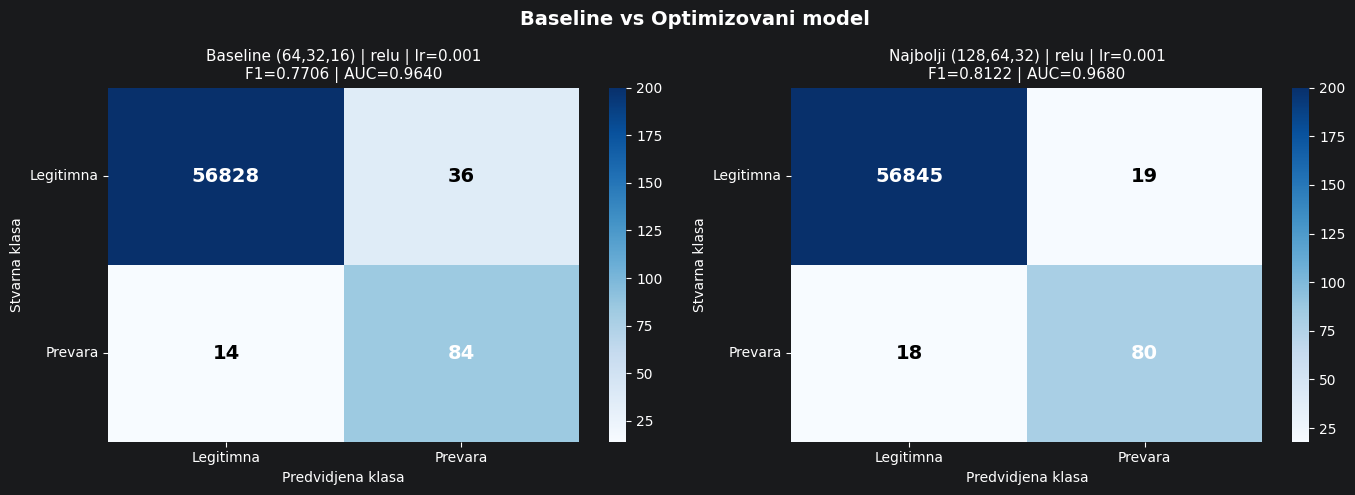

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, y_prob, title in zip(
    axes,
    [y_pred_base, y_pred_best],
    [y_prob_base, y_prob_best],
    ['Baseline (64,32,16) | relu | lr=0.001', 'Najbolji (128,64,32) | relu | lr=0.001']
):
    cm = confusion_matrix(y_test, y_pred)
    sb.heatmap(cm, annot=False, cmap='Blues', ax=ax,
               xticklabels=['Legitimna', 'Prevara'],
               yticklabels=['Legitimna', 'Prevara'],
               cbar=True, vmax=200)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                    ha='center', va='center',
                    color='white' if cm[i, j] > 40 else 'black', fontsize=14, fontweight='bold')
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    ax.set_title(f'{title}\nF1={f1:.4f} | AUC={auc:.4f}', fontsize=11)
    ax.set_ylabel('Stvarna klasa')
    ax.set_xlabel('Predvidjena klasa')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.suptitle('Baseline vs Optimizovani model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Finalno poređenje i ROC kriva
Tabelarni pregled svih metrika oba modela i njihove ROC krive na istom grafikonu radi direktnog poređenja.

FINALNO POREĐENJE
                   Model Activation  Learning Rate  Precision (fraud)  Recall (fraud)  F1 (fraud)  AUC-ROC
     Baseline (64,32,16)       relu          0.001               0.70            0.86    0.770642 0.928255
Optimizovani (128,64,32)       relu          0.001               0.81            0.82    0.812183 0.967991


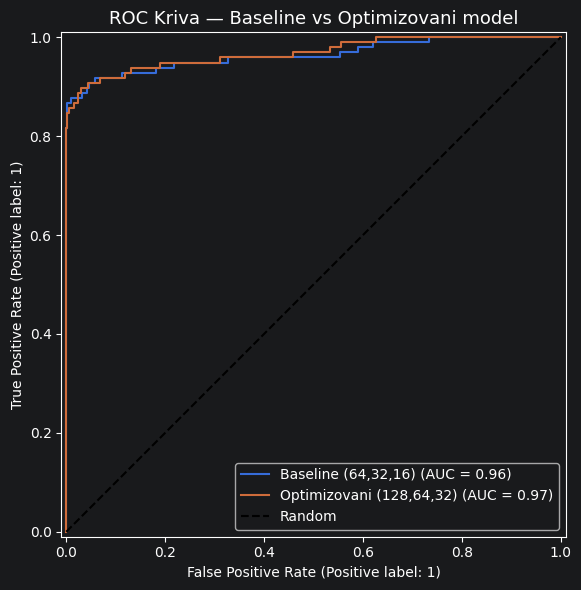

In [10]:
summary = pd.DataFrame({
    'Model': ['Baseline (64,32,16)', 'Optimizovani (128,64,32)'],
    'Activation': ['relu', 'relu'],
    'Learning Rate': [0.001, 0.001],
    'Precision (fraud)': [0.70, 0.81],
    'Recall (fraud)': [0.86, 0.82],
    'F1 (fraud)': [baseline_f1, f1_score(y_test, y_pred_best)],
    'AUC-ROC': [baseline_auc, roc_auc_score(y_test, y_prob_best)]
})

print('FINALNO POREĐENJE')
print(summary.to_string(index=False))


fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_base, ax=ax, name='Baseline (64,32,16)')
RocCurveDisplay.from_predictions(y_test, y_prob_best, ax=ax, name='Optimizovani (128,64,32)')
ax.set_title('ROC Kriva — Baseline vs Optimizovani model', fontsize=13)
ax.plot([0, 1], [0, 1], 'k--', label='Random')
plt.legend()
plt.tight_layout()
plt.show()


## Precision-Recall kriva — Baseline vs Optimizovani
Poređenje Precision-Recall krivih oba modela sa Average Precision skorom, relevantno za neuravnoteženi dataset.

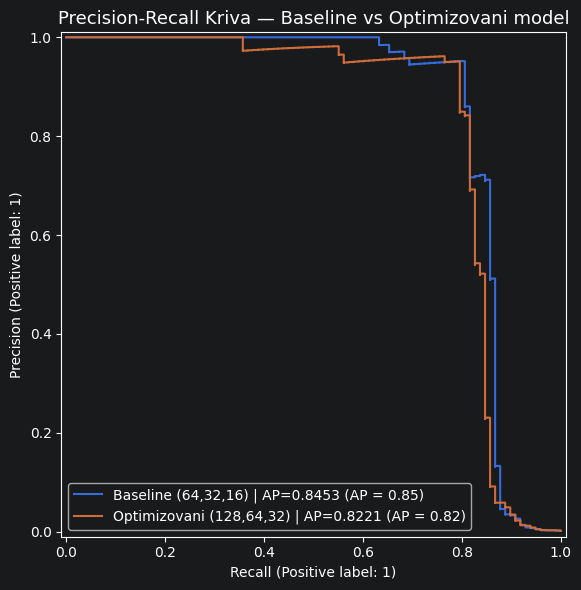

In [11]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

fig, ax = plt.subplots(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(
    y_test, y_prob_base, ax=ax,
    name=f'Baseline (64,32,16) | AP={average_precision_score(y_test, y_prob_base):.4f}'
)
PrecisionRecallDisplay.from_predictions(
    y_test, y_prob_best, ax=ax,
    name=f'Optimizovani (128,64,32) | AP={average_precision_score(y_test, y_prob_best):.4f}'
)

ax.set_title('Precision-Recall Kriva — Baseline vs Optimizovani model', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## Analiza osetljivosti — Permutation Importance
Mjerimo koliko svaki feature doprinosi F1 skoru baseline modela nasumičnim miješanjem njegovih vrijednosti.

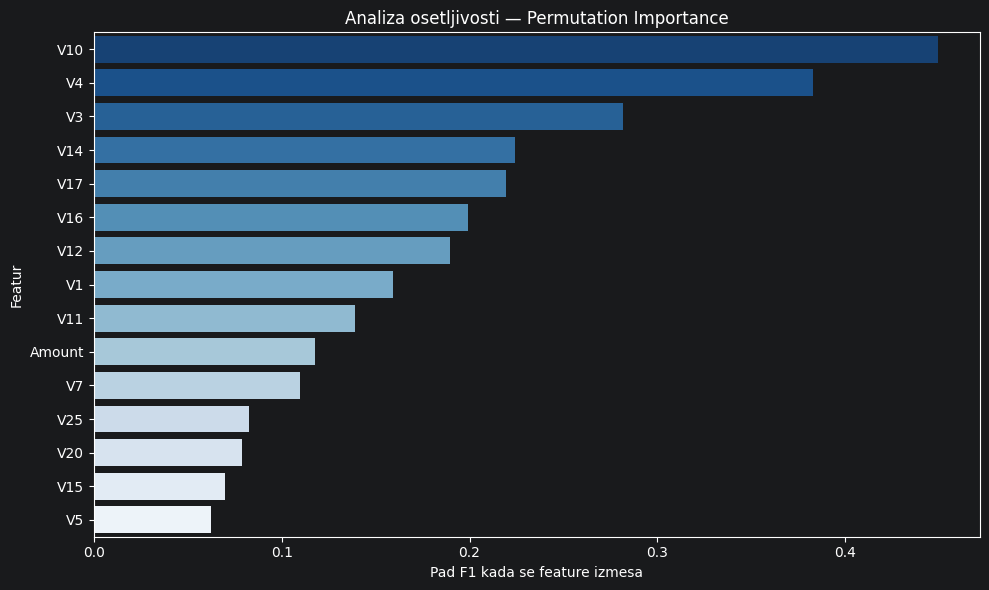

In [12]:
#analiza osetljivosti
from sklearn.inspection import permutation_importance

result = permutation_importance(
    baseline, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1'
)

importance_df = pd.DataFrame({
    'Featur': X_test.columns,
    'Vaznost': result.importances_mean
}).sort_values('Vaznost', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sb.barplot(x='Vaznost', y='Featur', data=importance_df, palette='Blues_r')
plt.title('Analiza osetljivosti — Permutation Importance')
plt.xlabel('Pad F1 kada se feature izmesa')
plt.tight_layout()
plt.show()

## Heatmapa rezultata grid searcha
Vizualizujemo F1 skorove svih kombinacija arhitektura i stopa učenja odvojeno za ReLU i Tanh aktivacionu funkciju.

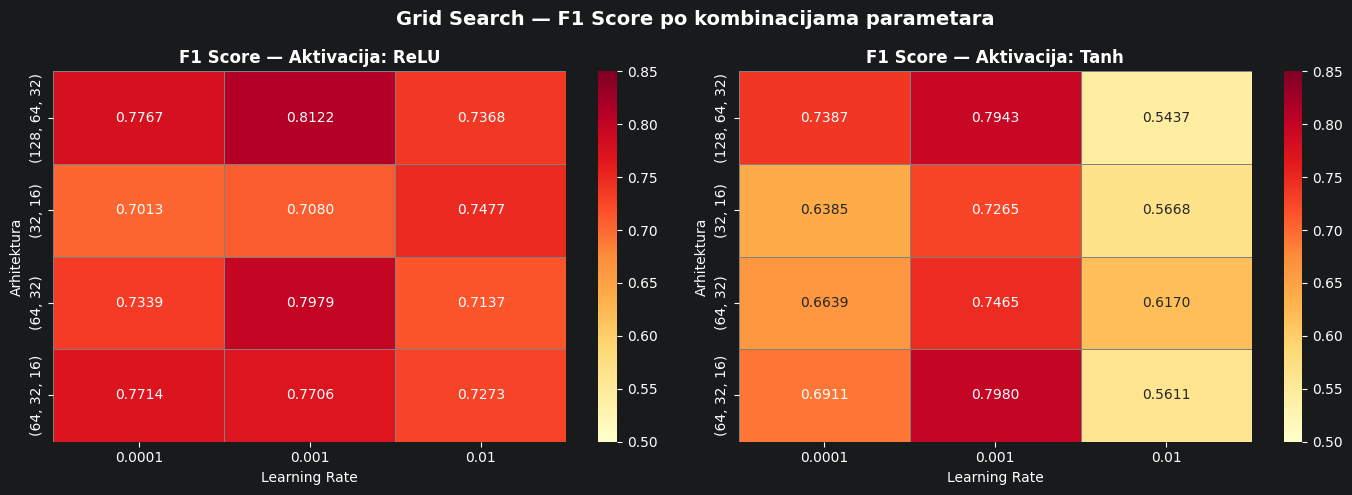

In [13]:
pivot_relu = pd.DataFrame(results)[pd.DataFrame(results)['activation'] == 'relu'].pivot(
    index='hidden_layer_sizes', columns='learning_rate_init', values='f1'
)
pivot_tanh = pd.DataFrame(results)[pd.DataFrame(results)['activation'] == 'tanh'].pivot(
    index='hidden_layer_sizes', columns='learning_rate_init', values='f1'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5)) 

for ax, pivot, title in zip(
    axes,
    [pivot_relu, pivot_tanh],
    ['Aktivacija: ReLU', 'Aktivacija: Tanh']
):
    sb.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd',
               ax=ax, vmin=0.5, vmax=0.85,
               linewidths=0.5, linecolor='gray')
    ax.set_title(f'F1 Score — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Learning Rate')
    ax.set_ylabel('Arhitektura')

plt.suptitle('Grid Search — F1 Score po kombinacijama parametara', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()